# Caso 2: Wine Quality - Análisis Exploratorio y Modelado Predictivo

**Asignatura:** Inteligencia Artificial / Aprendizaje Automático - 2026-II

**Objetivo:** predecir la calidad del vino (escala 0-10) a partir de 11 propiedades físico-químicas usando **Regresión Lineal Múltiple** y **Regresión Polinomial**.

**Dataset:** Wine Quality (UCI) - https://archive.ics.uci.edu/dataset/186/wine+quality - subconjunto de **vino tinto** (1599 registros).

## 1. Importación de librerías

Cargamos las librerías necesarias: `pandas`/`numpy` para datos, `matplotlib`/`seaborn` para gráficos, `sklearn` para el modelado y `joblib` para guardar los modelos entrenados.

In [1]:
%matplotlib inline
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Carga del dataset

El CSV se encuentra en `data/winequality-red.csv`. La copia local está separada por **comas** (`,`), a diferencia del original de UCI que usa punto y coma (`;`), por eso se indica `sep=','`. La ruta se resuelve automáticamente tanto si el notebook se ejecuta desde `notebooks/` como desde la raíz de `caso2/`.

In [2]:
candidatos_csv = ["../data/winequality-red.csv", "data/winequality-red.csv", "caso2/data/winequality-red.csv"]
RUTA_CSV = next(p for p in candidatos_csv if os.path.exists(p))

df = pd.read_csv(RUTA_CSV, sep=",")

print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Exploración inicial: nulos, duplicados y estadísticos

Revisamos la estructura del DataFrame, la presencia de **valores nulos** (el dataset de UCI viene limpio, pero se verifica) y los estadísticos descriptivos de cada variable.

In [3]:
df.info()
print("-" * 60)
print("Valores nulos por columna:\n", df.isna().sum())
print("-" * 60)
print("Filas duplicadas:", df.duplicated().sum())
print("-" * 60)
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
------------------------------------------------------------
Valores nulos por columna:
 fixed acidity           0
volatile acidity      

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 4. Detección de outliers con boxplots

Un boxplot muestra la mediana, los cuartiles y los valores atípicos de cada variable físico-química. Se observa que variables como `residual sugar`, `chlorides` o `total sulfur dioxide` tienen colas largas hacia la derecha (distribución sesgada con outliers), mientras que `density` está muy concentrada en un rango pequeño. No eliminamos los outliers: en regresión conviene conservarlos y dejar que la estandarización los acote.

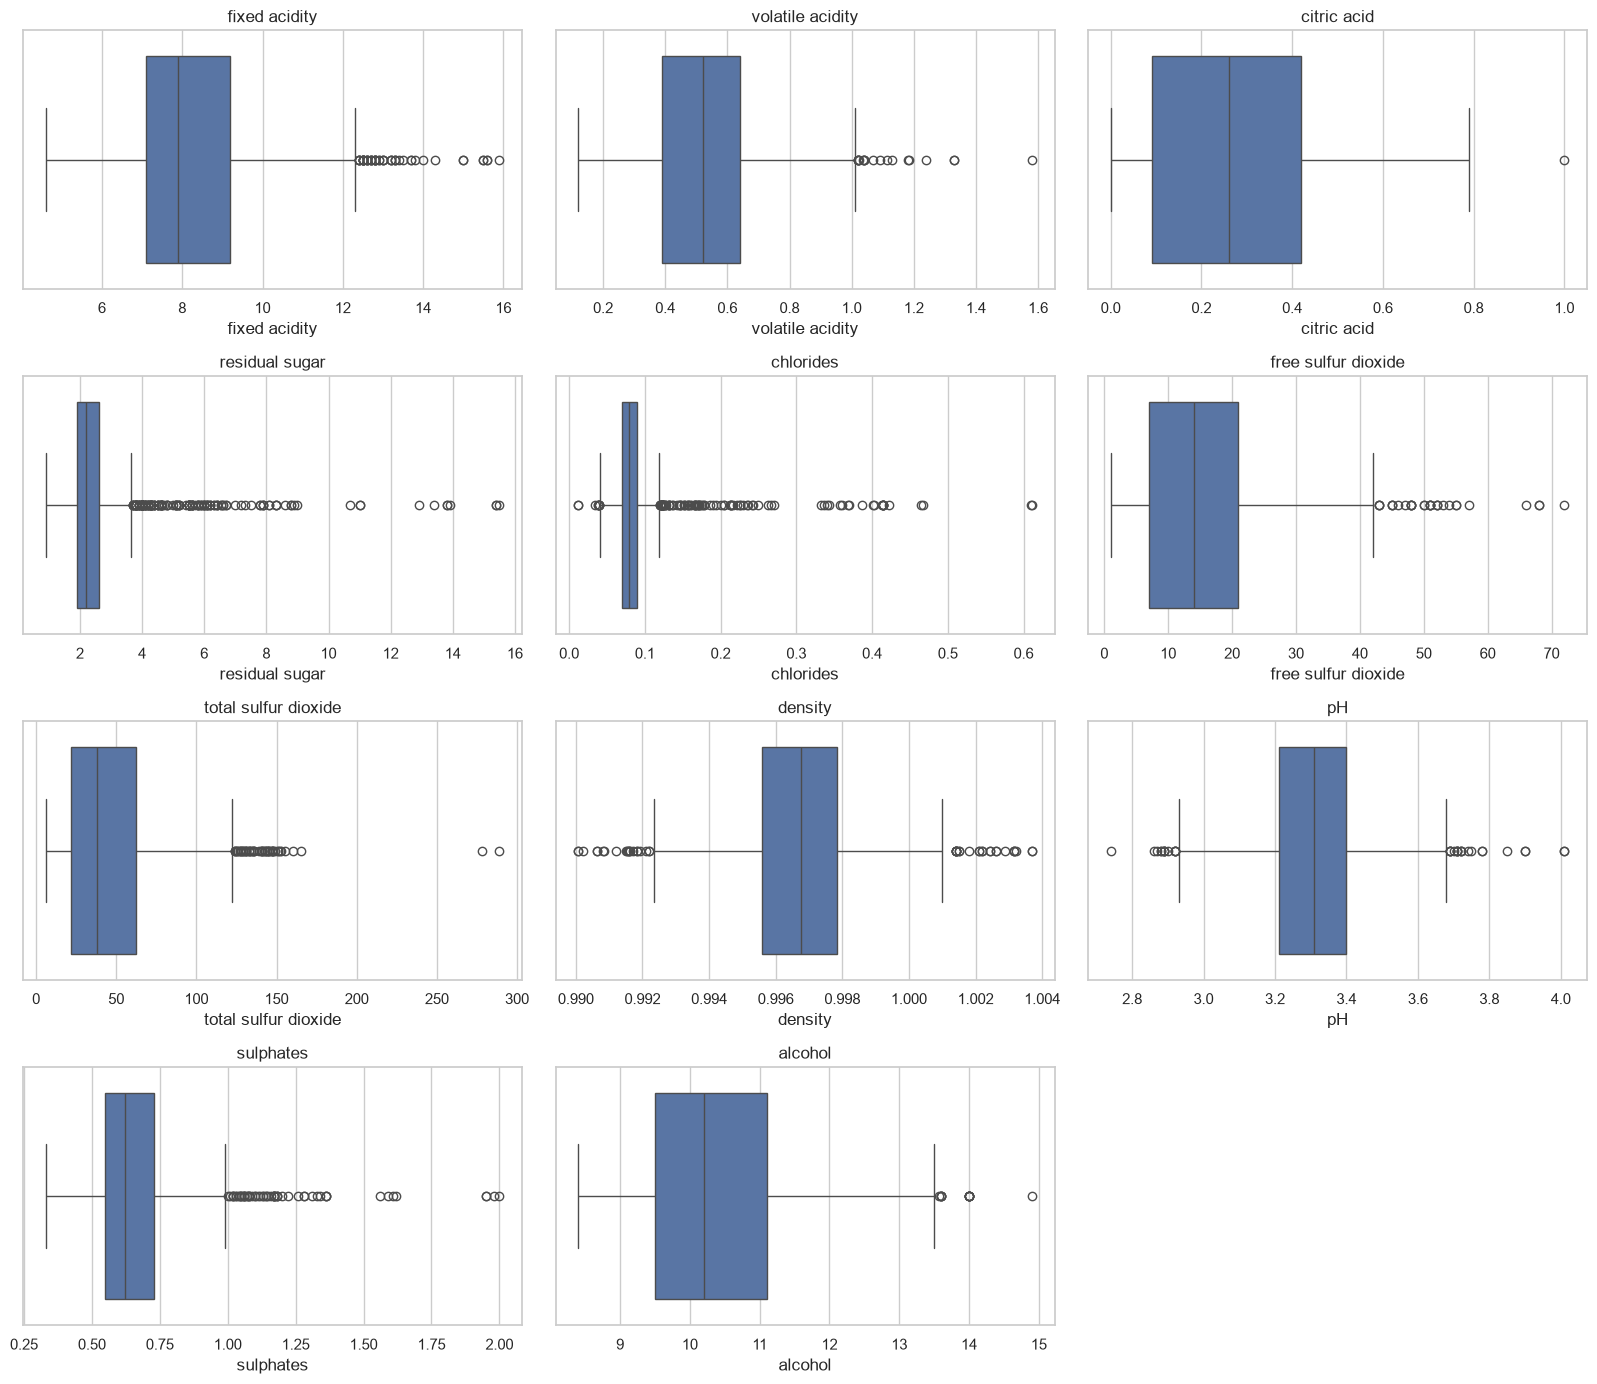

Conteo de outliers por regla IQR (fuera de Q1 - 1.5*IQR y Q3 + 1.5*IQR):
  fixed acidity                outliers: 49
  volatile acidity             outliers: 19
  citric acid                  outliers: 1
  residual sugar               outliers: 155
  chlorides                    outliers: 112
  free sulfur dioxide          outliers: 30
  total sulfur dioxide         outliers: 55
  density                      outliers: 45
  pH                           outliers: 35
  sulphates                    outliers: 59
  alcohol                      outliers: 13


In [4]:
cols_fisico_quimicas = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for ax, col in zip(axes, cols_fisico_quimicas):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Conteo de outliers por regla IQR (fuera de Q1 - 1.5*IQR y Q3 + 1.5*IQR):")
for col in cols_fisico_quimicas:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:28s} outliers: {n_out}")

## 5. Matriz de correlación

El heatmap permite detectar relaciones fuertes entre variables: `fixed acidity` con `citric acid` y con `density`, `density` con `alcohol` (negativa) y `free sulfur dioxide` con `total sulfur dioxide`. La variable más correlacionada con **quality** es `alcohol` (positiva), seguida de `volatile acidity` (negativa) y `sulphates` (positiva).

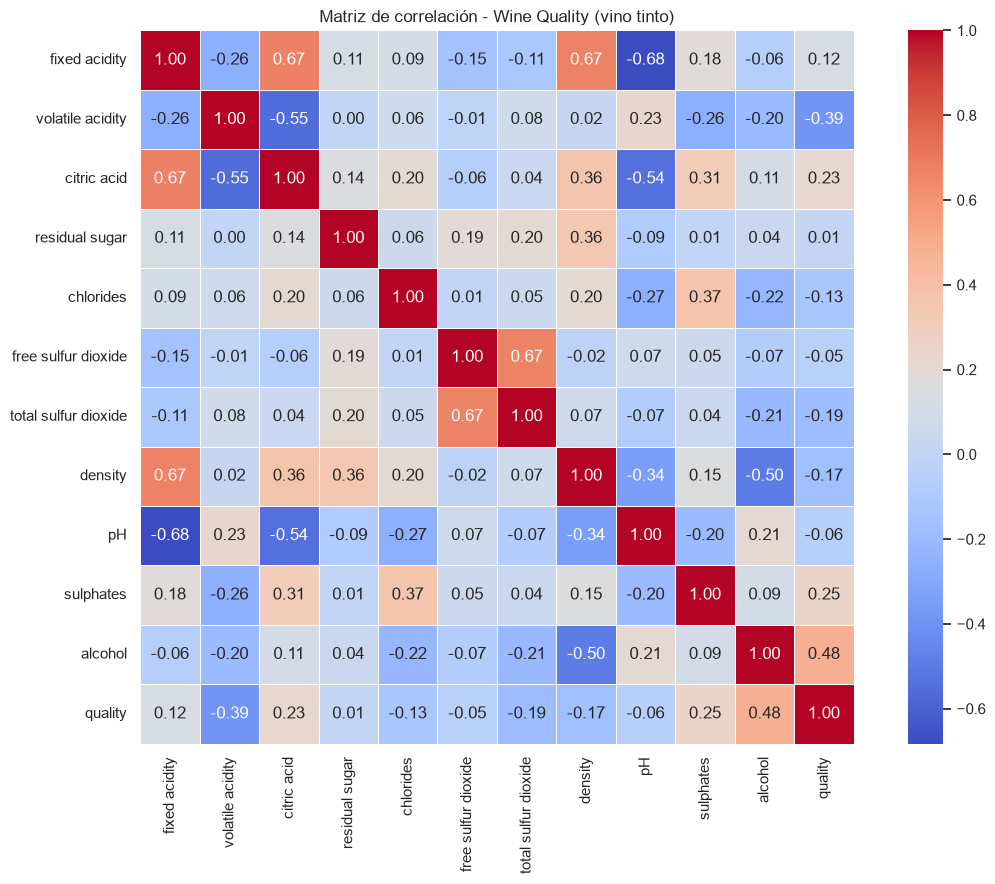

Correlación de cada variable con quality:

alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64


In [5]:
corr = df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Matriz de correlación - Wine Quality (vino tinto)")
plt.tight_layout()
plt.show()

corr_con_quality = corr["quality"].drop("quality").sort_values(ascending=False)
print("Correlación de cada variable con quality:\n")
print(corr_con_quality.round(3))

## 6. Multicolinealidad: VIF (Variance Inflation Factor)

El VIF mide cuánto se infla la varianza de un coeficiente por la correlación con el resto de variables. Regla común: **VIF > 10** indica multicolinealidad severa (VIF > 5 ya es señal de alerta). Se calcula como 1 / (1 - R²), donde R² proviene de regresar cada variable contra las demás.

In [6]:
def calcular_vif(X):
    """VIF de cada columna de X usando R^2 de regresión contra el resto."""
    vifs = {}
    for col in X.columns:
        resto = X.drop(columns=[col])
        reg = LinearRegression()
        reg.fit(resto, X[col])
        r2 = reg.score(resto, X[col])
        vifs[col] = 1 / (1 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

X_raw = df.drop(columns=["quality"])
vif = calcular_vif(X_raw)
print("VIF por variable (ordenado de mayor a menor):\n")
print(vif.round(3))

VIF por variable (ordenado de mayor a menor):

fixed acidity           7.768
density                 6.344
pH                      3.330
citric acid             3.128
alcohol                 3.031
total sulfur dioxide    2.187
free sulfur dioxide     1.963
volatile acidity        1.789
residual sugar          1.703
chlorides               1.482
sulphates               1.429
dtype: float64


## 7. Estandarización con StandardScaler

Se estandarizan **solo las variables predictoras** (media 0, desviación 1). La variable `quality` es el **target** y **no** se escala. El scaler se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información (*data leakage*) hacia el test.

In [7]:
y = df["quality"].values
X = df.drop(columns=["quality"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

idx_alcohol = X.columns.get_loc("alcohol")
print("Ejemplo (alcohol) - antes  : media", X_train["alcohol"].mean().round(3),
      "| desviación", X_train["alcohol"].std().round(3))
print("Ejemplo (alcohol) - después: media", X_train_s[:, idx_alcohol].mean().round(6),
      "| desviación", X_train_s[:, idx_alcohol].std().round(3))

Ejemplo (alcohol) - antes  : media 10.418 | desviación 1.053
Ejemplo (alcohol) - después: media 0.0 | desviación 1.0


## 8. Modelo 1: Regresión Lineal Múltiple

Se entrena sobre las 11 variables ya estandarizadas. Los coeficientes estandarizados permiten comparar la influencia relativa de cada variable sobre la calidad.

In [8]:
def evaluar(y_true, y_pred):
    """Retorna R2, RMSE y MAE de una predicción."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_s, y_train)

pred_train = modelo_lineal.predict(X_train_s)
pred_test = modelo_lineal.predict(X_test_s)

m_lineal_train = evaluar(y_train, pred_train)
m_lineal_test = evaluar(y_test, pred_test)
print("Regresión Lineal Múltiple - train:", {k: round(v, 4) for k, v in m_lineal_train.items()})
print("Regresión Lineal Múltiple - test :", {k: round(v, 4) for k, v in m_lineal_test.items()})

coefs = pd.Series(modelo_lineal.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nVariables con mayor influencia (coeficiente estandarizado):")
print(coefs.round(3))

Regresión Lineal Múltiple - train: {'R2': 0.348, 'RMSE': np.float64(0.6513), 'MAE': 0.4996}
Regresión Lineal Múltiple - test : {'R2': 0.4032, 'RMSE': np.float64(0.6245), 'MAE': 0.5035}

Variables con mayor influencia (coeficiente estandarizado):
alcohol                 0.297
volatile acidity       -0.179
sulphates               0.147
total sulfur dioxide   -0.120
chlorides              -0.089
pH                     -0.061
free sulfur dioxide     0.058
fixed acidity           0.040
citric acid            -0.028
density                -0.019
residual sugar          0.009
dtype: float64


## 9. Modelos 2 y 3: Regresión Polinomial (grados 2 y 3)

Se usan **solo las 3 variables con mayor correlación absoluta con `quality`** (alcohol, volatile acidity y sulphates): un polinomio con las 11 variables generaría cientos de términos e inestabilidad numérica. Cada modelo es un `Pipeline`: escalado → términos polinomiales (`PolynomialFeatures`) → regresión lineal.

In [9]:
top_k = corr_con_quality.abs().sort_values(ascending=False).head(3).index.tolist()
print("Variables seleccionadas para el polinomio:", top_k)

modelos_poly = {}
for grado in [2, 3]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression()),
    ])
    pipe.fit(X_train[top_k], y_train)
    modelos_poly[grado] = pipe

    m_train = evaluar(y_train, pipe.predict(X_train[top_k]))
    m_test = evaluar(y_test, pipe.predict(X_test[top_k]))
    print(f"Polinomial grado {grado} - train:", {k: round(v, 4) for k, v in m_train.items()})
    print(f"Polinomial grado {grado} - test :", {k: round(v, 4) for k, v in m_test.items()})

Variables seleccionadas para el polinomio: ['alcohol', 'volatile acidity', 'sulphates']
Polinomial grado 2 - train: {'R2': 0.3517, 'RMSE': np.float64(0.6495), 'MAE': 0.5021}
Polinomial grado 2 - test : {'R2': 0.4071, 'RMSE': np.float64(0.6225), 'MAE': 0.5083}
Polinomial grado 3 - train: {'R2': 0.3716, 'RMSE': np.float64(0.6394), 'MAE': 0.4952}
Polinomial grado 3 - test : {'R2': 0.4249, 'RMSE': np.float64(0.6131), 'MAE': 0.4975}


## 10. Comparativa de modelos

Tabla resumen con R², RMSE y MAE (en train y en test) para los tres modelos. El criterio de selección es el desempeño en **test**, no en train.

In [10]:
resumen = {
    "Regresión Lineal Múltiple": (m_lineal_train, m_lineal_test),
    "Polinomial grado 2": (
        evaluar(y_train, modelos_poly[2].predict(X_train[top_k])),
        evaluar(y_test, modelos_poly[2].predict(X_test[top_k])),
    ),
    "Polinomial grado 3": (
        evaluar(y_train, modelos_poly[3].predict(X_train[top_k])),
        evaluar(y_test, modelos_poly[3].predict(X_test[top_k])),
    ),
}

tabla = pd.DataFrame({
    "R2 train": [v[0]["R2"] for v in resumen.values()],
    "R2 test": [v[1]["R2"] for v in resumen.values()],
    "RMSE train": [v[0]["RMSE"] for v in resumen.values()],
    "RMSE test": [v[1]["RMSE"] for v in resumen.values()],
    "MAE train": [v[0]["MAE"] for v in resumen.values()],
    "MAE test": [v[1]["MAE"] for v in resumen.values()],
}, index=resumen.keys()).round(4)

tabla

,R2 train,R2 test,RMSE train,RMSE test,MAE train,MAE test
Regresión Lineal Múltiple,0.3480,0.4032,0.6513,0.6245,0.4996,0.5035
Polinomial grado 2,0.3517,0.4071,0.6495,0.6225,0.5021,0.5083
Polinomial grado 3,0.3716,0.4249,0.6394,0.6131,0.4952,0.4975


## 11. Guardado del mejor modelo con joblib

Se guarda en `modelos/mejor_modelo.pkl` un diccionario con el modelo ganador, su scaler y (si aplica) el `PolynomialFeatures`, además de `modelos/scaler.pkl`. La app `app_caso2.py` carga estos artefactos para predecir en tiempo real.

In [11]:
mejor = tabla["R2 test"].idxmax()
print("Mejor modelo según R2 en test:", mejor)

if mejor == "Regresión Lineal Múltiple":
    artefacto = {
        "modelo": modelo_lineal,
        "scaler": scaler,
        "poly": None,
        "columnas_modelo": list(X.columns),
        "columnas_entrada": list(X.columns),
    }
else:
    grado = 2 if "grado 2" in mejor else 3
    pipe = modelos_poly[grado]
    artefacto = {
        "modelo": pipe.named_steps["reg"],
        "scaler": pipe.named_steps["scaler"],
        "poly": pipe.named_steps["poly"],
        "columnas_modelo": top_k,
        "columnas_entrada": list(X.columns),
    }

RUTA_MODELOS = next(p for p in ["../modelos", "modelos", "caso2/modelos"] if os.path.isdir(p))
os.makedirs(RUTA_MODELOS, exist_ok=True)
joblib.dump(artefacto, os.path.join(RUTA_MODELOS, "mejor_modelo.pkl"))
joblib.dump(artefacto["scaler"], os.path.join(RUTA_MODELOS, "scaler.pkl"))

print("Carpeta de modelos:", os.path.abspath(RUTA_MODELOS))
print("Guardado: mejor_modelo.pkl y scaler.pkl")
print("Contenido del artefacto:")
for k, v in artefacto.items():
    print(f"  {k}: {v if isinstance(v, (list, type(None))) else type(v).__name__}")

Mejor modelo según R2 en test: Polinomial grado 3
Carpeta de modelos: D:\2026UAC\IA\caso 2\caso2\modelos
Guardado: mejor_modelo.pkl y scaler.pkl
Contenido del artefacto:
  modelo: LinearRegression
  scaler: StandardScaler
  poly: PolynomialFeatures
  columnas_modelo: ['alcohol', 'volatile acidity', 'sulphates']
  columnas_entrada: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 12. Conclusiones

**¿Cuál funcionó mejor y por qué?** Según la tabla, la **Regresión Polinomial de grado 3** obtuvo el mejor desempeño en test (R² = 0.4249), superando por poco a la Regresión Lineal Múltiple (R² = 0.4032) y al grado 2 (R² = 0.4071). La mejora es modesta y confirma que la relación entre las propiedades físico-químicas y la calidad es **débil y aproximadamente lineal**: la calidad es una etiqueta ordinal discreta (0-10) asignada por catadores, con mucho ruido intrínseco.

**Riesgo de overfitting en el polinomial de grado 3:** el grado 3 genera muchos más términos (20 features con 3 variables) y tiende a memorizar el train: aquí la ganancia sobre el grado 2 es pequeña y, en datasets o splits menos favorables, el R² de test suele caer por debajo del lineal. El criterio de selección siempre es el desempeño en **test** y, ante empate, se prefiere el modelo más simple (navaja de Occam).

**Siguiente paso:** la app `app_caso2.py` carga `modelos/mejor_modelo.pkl` y `modelos/scaler.pkl` para predecir la calidad de un vino a partir de sus 11 propiedades físico-químicas.